Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [2]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
from __future__ import print_function
%matplotlib inline
%precision 16
import numpy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# HW 6:  ODE Methods - Boundary Value Problems

This homework will combine a lot of previous codes to solve simple linear and non-linear Boundary value problems

This problem set has two questions

## Question 1 - A linear ODE BVP

Consider the *linear* non-homogeneous 2-pt boundary value problem

$$
    u^{\prime\prime}+ u = \sin3x\quad\quad x\in[0,L],\quad u(0)=u(L)=0
$$

which is related to the modes of vibration of a forced string of length $L$.

**(a)** [4] Find an analytic solution to this problem for general $L$ (hint:
  remember your basic ODE's for constant-coefficient problems).  Is
  this solution unique?

For a non-homogenous second-order ordinary differential equation (ODE), we can write the solution as $u(x) = u_H(x) + u_P(x)$. First, let us find the homogeneous solution, $u_H$.

To find $u_H$, we examine the characteristic polynomial of the associated homogeneous ODE.
$$
u''+u=0 \\
z^2 + 1 = 0 \\
z = \pm i \\
u_H(x) = c_1 sin(x) + c_2 cos(x)
$$

To find $u_P$, we use the method of undetermined coefficients. We start this method by making a guess for the form of $u_P$ based on the sinusoidal form of the right-hand side of our ODE:
$$
u_P(x) = c_3 sin(3x) +c_4 cos(3x) \\
u_P'' = -9c_3sin(3x) - 9c_4cos(3x)
$$
Plugging into the initial ODE:
$$
-9c_3sin(3x) - 9c_4cos(3x) + c_3 sin(3x) +c_4 cos(3x) = sin(3x)
$$
Matching terms on either side of the equals sign, it is clear $c_4=0$. For $c_3$:
$$
-9c_3sin(3x) + c_3 sin(3x) = sin(3x) \\
-9c_3 + c_3 = 1\\
c_3 = \frac{-1}{8}
$$

Now we can plug in our boundary conditions for the full $u(x)$.
$$
u(x) = c_1 sin(x) + c_2 cos(x) - \frac{1}{8}sin(3x)
$$
First, examine the $x=0$ boundary condition:
$$
0 = 0 + c_2 - 0 \\
c_2 = 0
$$
Next, examine the $x=L$ boundary condition:
$$
0 = c_1 sin(L) - \frac{1}{8}sin(3L) \\ 
c_1 = \frac{sin(3L)}{8sin(L)}
$$

Thus our full solution is:
$$
u(x) = \frac{sin(3L)}{8sin(L)} sin(x) - \frac{1}{8}sin(3x)
$$

This solution is unique!

**(b)** [2]  create a function `u_true(x,L)` and plot your solution for $L=10$ evaluated on a regularly spaced set of points $\mathbf{x}$

In [5]:
L = 10.
N = 200
x = numpy.linspace(0., L, N)

def u_true(x,L):
    """
    Analytic solution to part (a) of this problem
        
    parameters:
    -----------
    x: numpy array
        coordinates array for solution on interval [0,L] with x[0] = 0, x[-1] = L
    L: int
        interval length
        
    returns:
    --------
    u: numpy array, solution u(x)
    """

    return numpy.sin(3*L)*numpy.sin(x)/(8*numpy.sin(L)) - numpy.sin(3*x)/8

**(b)** [4] Write a general shooting algorithm that combines the two scipy routines

* scipy.integrate.solve_ivp
* scipy.optimized.root_scalar

and returns the solution evaluated at an evenly spaced set of points $\mathbf{x}$.  

Some hints

* use `dense_output = True` in solve_ivp
* you can introduce a second def within shoot_bvp for use in root_scalar

For convenience (and testing), I've provided the interface introduced in class for a routine that can handle a range of boundary conditions and can control relative and absolute tolerance.

In [27]:
# write a general shooting algorithm
# ASSUME f HAS FORM u'' = f(x, u, u')

from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

def shoot_bvp(f, x, u_a, u_b, i_a, i_b, rtol=5.e-7, atol=1.e-9):
    """
    Solve the two-point boundary value problem on the interval x\\in [a,b], using a shooting method that combines 
        scipy.integrate.solve_ivp and scipy.optimize.root_scalar and allows a range of boundary conditions
        
        
    parameters:
    -----------
    f: calleable 
        vector value function for righthand side of the ODE with interface f(t,u). returns ndarray of length 2
    x: numpy array
        coordinates array for solution  on interval [a,b] with x[0] = a, x[-1] = b
    u_a:  numpy array (length 2)
        provide initial boundary conditions  [u, u' ] at x=a
    u_b:  numpy array (length 2)
        target boundary condition at x = b
    i_a: integer
        index of known boundary condition at x = a.  i.e.
        if dirichlet conditions : i_a = 0 and u(a) is known  
        if neumann conditions   : i_a = 1 and u'(a) is known
        the complementary index is adjusted to match the boundary condition at b
    i_b: integer
        index of known boundary condition at x = b. i.e.
        if dirichlet conditions : i_b = 0 and u(b) is known  
        if neumann conditions   : i_b = 1 and u'(b) is known
        the complementary index is ignored at b
    rtol:  float
        relative tolerance
    atol:  float
        absolute tolerance
        
    returns:
    --------
    u: solution u(x) for x (uses dense_output from solve_ivp to interpolate solution onto x)
    """

    # Set up first-order ODE system
    def dvdx_f(x,v):
        v1,v2 = v # u, ux
        return numpy.array([
            v2,
            f(x,v1,v2)
        ])
    
    # Solve first-order ODE system with intitial guess for u2(b) #
    # u_a[1 - i_a] = numpy.random.uniform(x[0],x[-1]) # a guess for the bc at x=a that contains the non-specified bc
    # we will find the value of u_a at this unknown bc that will gaurantee the specified bc at u_b is met
    # we can do this because if a second-order ODE has 2 bc, its solution is unique
    v0 = numpy.array(u_a, dtype=float)   # v0 = [u(a), u'(a)], must plug bc into solve_ivp at one x value
    
    def mismatch_bc(bcguess_val): # written as a function to keep the bcguess_val as a variable for the root_scalar function to take in
        v0[1 - i_a] = bcguess_val
        sol_init = solve_ivp(dvdx_f, [x[0],x[-1]], v0,rtol=rtol, atol=atol,dense_output=True) # gives v
        return sol_init.y[:,-1][i_b] - u_b[i_b]

    # Do root solve to find the guess of u_a[1 - i_a] should be to make mismatch_bc = 0
    bcguess_val_best = root_scalar(mismatch_bc,method='brentq',bracket=[-10,10])
    v0[1 - i_a] = bcguess_val_best.root # reset initial values at x=a with now known best value to match desired bc at x=b
    sol_final = solve_ivp(dvdx_f, [x[0],x[-1]], v0,rtol=rtol, atol=atol,dense_output=True) # gives v
    return sol_final.sol(x)[0]  # u(x) only (extract from [u, u'])


**(c)** [4] rewrite the original problem 

$$
    u^{\prime\prime} + u = \sin(3x)
$$

as a system of first order ODE's

$$
    \frac{d\mathbf{v}}{dx} = \mathbf{f}(x,\mathbf{v})
$$  

and solve using the interface

`u_sol = shoot_bvp(f, x, u_a, u_b, i_a, i_b)`

* make a plot comparing your shooting solution with the true solution.

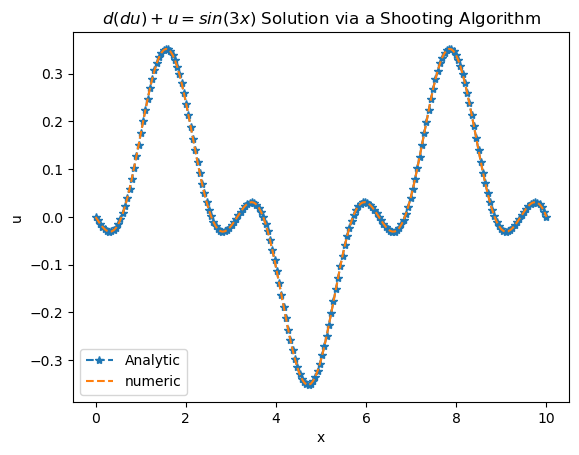

In [28]:
u_a = [0,0]
u_b = [0,0]
i_a = 0
i_b = 0
L = 10.
N = 200
x = numpy.linspace(0., L, N)
f = lambda x,v1,v2: -v1 + numpy.sin(3*x) # v1=u, v2=du/dx
u_sol = shoot_bvp(f, x, u_a, u_b, i_a, i_b)

fig,ax = plt.subplots()
ax.plot(x,u_true(x=x,L=L),'--*',label='Analytic')
ax.plot(x,u_sol,'--',label='numeric')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title(r'$d(du)+u=sin(3x)$ Solution via a Shooting Algorithm')
ax.legend()

The following cell tests your shooting code against the true solution.  Adjust the relative and absolute tolerances in shoot_bvp, to make sure the following test passes with relative error $<10^{-6}$

In [29]:
#  test the solution against the true solution and pass if relative error < 1.e-6

rel_err = numpy.linalg.norm(u_sol - u_true(x,L))/numpy.linalg.norm(u_true(x,L))
print('relative error = {}'.format(rel_err))

assert(rel_err < 1.e-6)
print('success')

relative error = 1.978715142848189e-07
success


**(d)** [8] Repeat the exercise but use the 2nd order finite difference methods introduced in class.  For convenience I have provided the routines for assembly of sparse 2nd derivative matrices and RHS from class.  

In [3]:
# routines from class  for generating 2nd order sparse second derivative operator and RHS vector

from fdcoeffV import fdcoeffV
from scipy.sparse import lil_matrix, identity, spdiags
from scipy.sparse.linalg import spsolve

def D2(x,bcs=['dirichlet', 'dirichlet']):
    """  
        Assemble a general sparse second-order finite-difference approximation to d/dx^2 on a possibly irregular mesh
        First and last rows are set by string bcs
        
        parameters:
        -----------
        x: numpy.array
            mesh coordinates
        bcs: list of strings for boundary conditions e.g [left_string, right_string] where
            the strings can be either 'dirichlet' or 'neumann'
    """
    N = len(x)
    A = lil_matrix((N,N))
    if bcs[0] == 'dirichlet':
        A[0,0] = 1.
    elif bcs[0] == 'neumann':
        A[0,0:3] = fdcoeffV(1,x[0],x[:3])
    else:
        raise ValueError('no known BC type for left boundary {}'.format(bcs[0]))
        
    if bcs[1] == 'dirichlet':
        A[-1,-1] = 1.
    elif bcs[1] == 'neumann':
        A[-1,-3:] = fdcoeffV(1,x[-1],x[-3:])
    else:
        raise ValueError('no known BC type for right boundary {}'.format(bcs[1]))
        
    for i in range(1,N-1):
        A[i, i-1:i+2] = fdcoeffV(2, x[i], x[i-1:i+2] )        
    return A.tocsr()

def RHS(x, f, bvalues):
    """ Set the rhs vector
    
        parameters
        ----------
        x: numpy.array
            mesh coordinates
        f: callable
            rhs function for interior points called on f(x[1:-2])
        bvalues:  numpy.array (len 2)
            values for boundary conditions (either dirichlet or neumann)        
    """
    
    N = len(x)
    rhs = numpy.empty(N)
    rhs[[0, N-1]] = bvalues
    rhs[1:-1] = f(x[1:-1])
    
    return rhs
    

Create a well-labeled convergence plot showing the relative error 

$$
    e_{rel} = \frac{|| u - u_{true} ||}{||u_{true}||}
$$

as a function of grid spacing $\Delta x$

This plot should calculate and show

* rate of convergence of error (i.e. find $p$ such that $e_{rel}\propto \Delta x^p$)
* an estimate of the  number of grid points $N$ required for the relative error to be $\leq 10^{-6}$
* the relative error at this smallest mesh spacing

Text(0, 0.5, 'Relative Error')

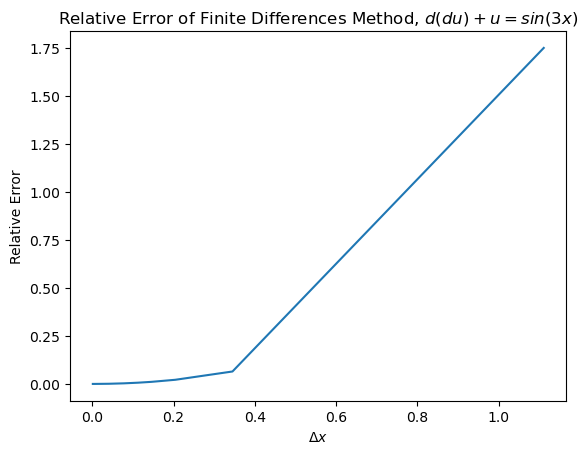

In [13]:
# Make a well labeled convergence plot that shows  convergence rate of relative error vs grid spacing
from scipy.sparse import identity
# N = 10
Ns = numpy.linspace(10,10000,500)
dx_arr = numpy.zeros(len(Ns))
err = numpy.zeros(len(Ns))
i=0
for N in Ns:
    a = 0 # x[0]
    b = 10 # L, x[-1]
    x = numpy.linspace(a, b, int(N))
    f_d = lambda x: numpy.sin(3*x) # can only handle functions of x

    A = D2(x,bcs=['dirichlet', 'dirichlet']) + identity(len(x)) # identity matrix takes into account the u term
    f = RHS(x=x, f=f_d, bvalues=[0., 0. ])
    u = spsolve(A,f)

    # u_true
    u_true_N = u_true(x=x,L=10)

    dx_arr[i] = x[1] - x[0]

    # err
    err[i] = numpy.linalg.norm(u - u_true_N) / numpy.linalg.norm(u_true_N)

    i+=1
numpy.save('err.npy',err)
numpy.save('dx_arr.npy',dx_arr)
fig1,ax1 = plt.subplots()
ax1.plot(dx_arr,err)
ax1.set_title(r'Relative Error of Finite Differences Method, $d(du)+u=sin(3x)$')
ax1.set_xlabel(r'$\Delta x$')
ax1.set_ylabel('Relative Error')

Spacing for relative error = 1.e-6: 0.001405283867341203
Relative error at this spacing: 9.979747983218925e-07
Spacing for minimum relative error: 0.001000100010001
Relative error at this spacing: 5.05440527222181e-07
Rate of convergence: 2.00005588087049
This rate of convergence is consistent with the second order accuracy of the finite difference method.


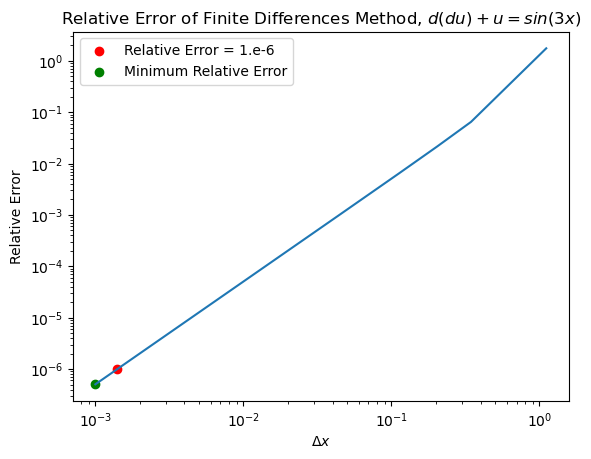

In [23]:
dx_arr=numpy.load('dx_arr.npy')
err=numpy.load('err.npy')
fig1,ax1 = plt.subplots()
ax1.loglog(dx_arr,err)
ax1.set_title(r'Relative Error of Finite Differences Method, $d(du)+u=sin(3x)$')
ax1.set_xlabel(r'$\Delta x$')
ax1.set_ylabel('Relative Error')

argmin_err = numpy.argmin(abs(err - 1.e-6))
print('Spacing for relative error = 1.e-6: {}'.format(dx_arr[argmin_err]))
print('Relative error at this spacing: {}'.format(err[argmin_err]))
ax1.scatter(dx_arr[argmin_err],err[argmin_err],color='red',label='Relative Error = 1.e-6')
argmin_err_global = numpy.argmin(err)
print('Spacing for minimum relative error: {}'.format(dx_arr[argmin_err_global]))
print('Relative error at this spacing: {}'.format(err[argmin_err_global]))
ax1.scatter(dx_arr[argmin_err_global],err[argmin_err_global],color='green',label='Minimum Relative Error')
ax1.legend()

rate_of_convergence = numpy.log(err[argmin_err_global] / err[argmin_err]) / numpy.log(dx_arr[argmin_err_global] / dx_arr[argmin_err])
print('Rate of convergence: {}'.format(rate_of_convergence))
print('This rate of convergence is consistent with the second order accuracy of the finite difference method.')


### Some themes and variations

This is meant to be a short problem set, but there are many other things to try if you are interested.

* Try this problem using Galerkin Finite Elements.  
* Try modifying the matrices to use higher order Finite difference schemes (i.e. 4th order schemes)
* Compare timing between Finite Difference and shooting schemes for the same order of accuracy


## Question 2 - Non-Linear Fun

try to solve the related  **non-linear** 2-point boundary value problem

$$
u^{\prime\prime}+\sin(u)=\sin(3x),\quad x\in[0,10],\quad u(0)=u(10)=0
$$

using  finite-difference plus Newton's method. For convenience, I've added the Newton Solver for sparse jacobians from the notes

In [ ]:
# a Newton Solver for sparse matrices
def newton(F,J,x0,tol=1.e-6,MAX_ITS=100,verbose=True):
    """ Solve F(x) = 0 using Newton's method until ||F(x)|| < tol or reaches Max iterations
    
    Params:
    -------
        F: calleable: 
            Function returning residual F(x)
        J: calleable
            Function returning Jacobian J(x)
        tol: float
            stopping criteria for ||F|| < tol
        MAX_ITS: integer
            maximum number of iterations
        verbose: bool
            if true spits out norm of the residual at each iteration
            
    Returns:
    --------
        x: numpy.array
            solution
        k: int
            number of iterations
    
    Raises:
    -----------
        ValueError if number of its exceeds MAX_ITS
        
    """
    x = x0 
    for k in range(MAX_ITS+1):
        res = numpy.linalg.norm(F(x))
        if verbose:
            print('k = {}, ||F|| = {}'.format(k,res))
        if res < tol: 
            return x, k
        delta = spsolve(J(x),-F(x))
        x += delta
        
    raise ValueError('Maximum number of iterations exceeded {}'.format(MAX_ITS))

**(a)** [4 pt]  Solve the problem for an initial guess
$u_0=0$. For this problem you will need to

* create a function to return the residual $\mathbf{F}(\mathbf{u})$
* create a function to return the Jacobian $J(\mathbf{u})$
* use `verbose=True` to see the convergence behavior of Newton
* produce a plot showing the solution and labeled with the number of newton iterations and final residual norm $||\mathbf{F}(\mathbf{u})||$

**Note:**  To choose a reasonable number of grid points, use your results from Question 1 and choose a mesh size such that the linear problem returns a relative error $< 10^{-3}$

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**(b)**  Is your solution unique?  Try starting newton from different
  periodic initial conditions 
  
  $$
      u_0(x) = \sin\left[\frac{n\pi x}{L}\right]
  $$ 
  
  for $n\in[0,6]$ that all satisfy the homogeneous boundary conditions. 
  
  Make two plots. 
  
  1. The first shows solutions for different values of $n$
  1. The second plots the residual $\mathbf{F}(\mathbf{u})$ to show that at least the discrete ODE is satisfied
  
 Welcome to the wonderful world of non-linear equations. Can you find any other solutions?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

### Extra Fun

Use your shooting routines to systematically search for non-linear solutions to this BVP problem by varying the initial guess for the initial slope $u'(0)$. How many solutions can you find?